# Objetivo do experimento
O objetivo deste experimento é avaliar o comportamento inicial do Algoritmo Genético (GA) aplicado à otimização de hiperparâmetros de uma rede neural MLP, utilizando uma configuração com mais diversidade.

Busca-se observar:

Convergência do algoritmo

Estabilidade do fitness ao longo das gerações

Capacidade de exploração do espaço de busca

## Configuração do Algoritmo Genético

A configuração adotada neste experimento foi:

Experimento 2 – Exploração moderada

Tamanho da população: 10

Gerações: 12

Taxa de mutação: 0.15

Taxa de cruzamento: 0.85

Elitismo: 1

Tamanho de torneio: 2

## Justificativa das escolhas:

Population size = 15
Valor aumentado para ampliar a diversidade genética da população, permitindo uma exploração mais abrangente do espaço de hiperparâmetros, mesmo com maior custo computacional.

Elitismo = 1
Mantém a melhor solução encontrada em cada geração, evitando regressão de desempenho, ao mesmo tempo em que permite maior liberdade exploratória para o restante da população.

Tournament size = 3
Aumenta a pressão seletiva em relação ao experimento 1, favorecendo indivíduos com melhor desempenho, mas ainda preservando diversidade genética.

Crossover rate = 0.9
Alta taxa de cruzamento para intensificar a recombinação genética entre indivíduos, acelerando a propagação de boas características na população.

Mutation rate = 0.25
Taxa de mutação elevada com o objetivo de aumentar a exploração do espaço de busca e reduzir o risco de convergência prematura.

Random seed = 42
Permite reprodutibilidade dos resultados.

## Execução do experimento

In [ ]:
from fase_2.ga.ga_runner import run_ga

HYPERPARAM_SPACE_EXP2 = {
    "n_hidden_layers": [1, 2],
    "n_neurons": [16, 32, 64],
    "learning_rate_init": [0.001, 0.01, 0.1],
    "activation": ["relu", "tanh"]
}

config_exp2 = {
    "population_size": 10,
    "generations": 12,
    "elite_size": 1,
    "tournament_size": 2,
    "crossover_rate": 0.85,
    "mutation_rate": 0.15,
    "random_seed": 42,
    "hyperparam_space": HYPERPARAM_SPACE_EXP2
}

result = run_ga(config_exp2)
result

## Resultados obtidos

Melhor indivíduo encontrado

In [2]:
result["best_individual"]

{'n_hidden_layers': 2,
 'n_neurons': 32,
 'learning_rate_init': 0.01,
 'activation': 'relu'}

## Melhor valor de fitness (F1-score)

In [3]:
result["best_fitness"]

0.7239819004524887

## Evolução do fitness ao longo das gerações

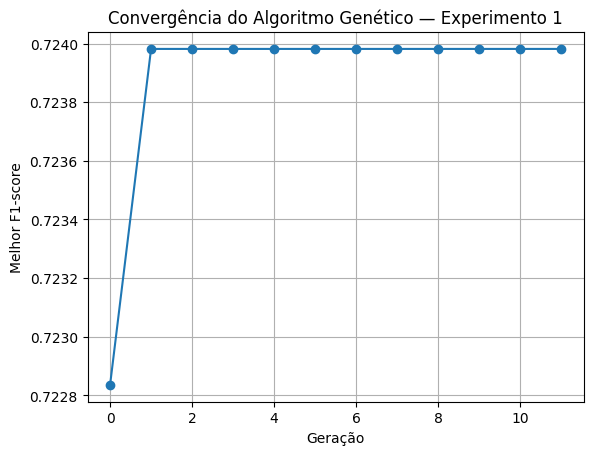

In [4]:
import matplotlib.pyplot as plt

plt.plot(result["fitness_history"], marker='o')
plt.xlabel("Geração")
plt.ylabel("Melhor F1-score")
plt.title("Convergência do Algoritmo Genético — Experimento 1")
plt.grid(True)
plt.show()

## Análise dos resultados

No Experimento 2, adotou-se uma configuração intermediária do Algoritmo Genético, com aumento moderado da população, do número de gerações e da taxa de mutação em relação ao Experimento 1, mantendo o custo computacional sob controle.

Apesar da ampliação do espaço de busca e do aumento do tempo de execução, o ganho observado no F1-score da classe positiva foi marginal quando comparado ao Experimento 1, permanecendo próximo de 0.72.

Esse comportamento sugere que o modelo MLP treinado na Fase 1 já se encontrava próximo de um ótimo local para o conjunto de dados analisado, limitando o potencial de melhoria obtido apenas por ajustes nos hiperparâmetros via Algoritmo Genético.

O aumento moderado da exploração promovido pelo Algoritmo Genético não resultou em ganhos proporcionais de desempenho, indicando possíveis limitações intrínsecas do modelo ou do próprio conjunto de dados.

## Comparativo com o modelo treinado sem otimização (Tech challenge fase 1)

In [5]:
from utils.module_diabetes import load_dataset, prepare_dataset, train_mlp
from fase_2.ga.fitness import calculate_fitness

baseline_params = {
    "hidden_layer_sizes": (16, 8)
}

df = load_dataset()
df_processed = prepare_dataset(df)
model, X_val, y_val = train_mlp(df_processed, baseline_params)
baseline_f1 = calculate_fitness(model, X_val, y_val)

baseline_f1

/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/jhonatan/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7164351851851852

In [8]:
import pandas as pd

pd.DataFrame({
    "Modelo": ["Baseline", "GA - Experimento 2"],
    "F1-score": [baseline_f1, result["best_fitness"]]
})


,Modelo,F1-score
0,Baseline,0.716435
1,GA - Experimento 1,0.723982


## Conclusão do experimento 2

Comparando os resultados obtidos pelo Algoritmo Genético no Experimento 2 com os resultados do Experimento 1 e com o modelo treinado na Fase 1, observa-se que o F1-score da classe positiva permaneceu praticamente estável, com variações marginais em torno de 0.72.

Apesar do aumento moderado da população, da taxa de mutação e da diversidade genética, os ganhos de desempenho foram limitados, especialmente quando considerados em relação ao aumento do custo computacional em comparação ao Experimento 1.

Esse comportamento indica que, mesmo com maior exploração do espaço de busca, o Algoritmo Genético encontrou restrições no conjunto de hiperparâmetros avaliados, sugerindo que o modelo MLP já se encontrava próximo de um ótimo local para o problema em questão.

O Experimento 2 demonstra que:

O aumento moderado da diversidade genética e da exploração do espaço de busca pode gerar pequenas variações no desempenho;

Esses ganhos tendem a ser marginais quando aplicados a um modelo previamente bem ajustado;

O custo computacional adicional deve ser cuidadosamente avaliado frente aos ganhos obtidos.

Os resultados obtidos reforçam a importância do balanceamento entre exploração e custo computacional, além de motivar a realização de um experimento adicional com configurações mais agressivas, com o objetivo de investigar os limites de convergência e estabilidade do Algoritmo Genético.